In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from pathlib import Path
from tensorflow.keras import layers, Sequential, callbacks, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
input_root = Path("/kaggle/input")

training_dirs = list(input_root.rglob("Training"))
testing_dirs = list(input_root.rglob("Testing"))

train_path = str(training_dirs[0])
test_path = str(testing_dirs[0])

print("Train path:", train_path)
print("Test path:", test_path)

Train path: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Test path: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing


In [3]:
batch_size = 32
img_height = 225
img_width = 225
seed = 123

train_ds = image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="categorical",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


I0000 00:00:1784179737.201170      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784179737.204300      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:
img_augmentation = Sequential([
    layers.RandomRotation(15/360),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.1),
], name="img_augmentation")

model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    img_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img_augmentation (Sequential)   │ (None, 225, 225, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 225, 225, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 225, 225, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 225, 225, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,748 (1.62 MB)

 Trainable params: 422,788 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    "best_custom_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5680 - loss: 1.0513
Epoch 1: val_loss improved from None to 1.36465, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 136ms/step - accuracy: 0.6319 - loss: 0.9126 - val_accuracy: 0.4295 - val_loss: 1.3646 - learning_rate: 1.0000e-04
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7227 - loss: 0.7357
Epoch 2: val_loss improved from 1.36465 to 1.17498, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 133ms/step - accuracy: 0.7272 - loss: 0.7058 - val_accuracy: 0.5018 - val_loss: 1.1750 - learning_rate: 1.0000e-04
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7554 - loss: 0.6184
Epoch 3: val_loss improved from 1.17498 to 0.98921, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
14

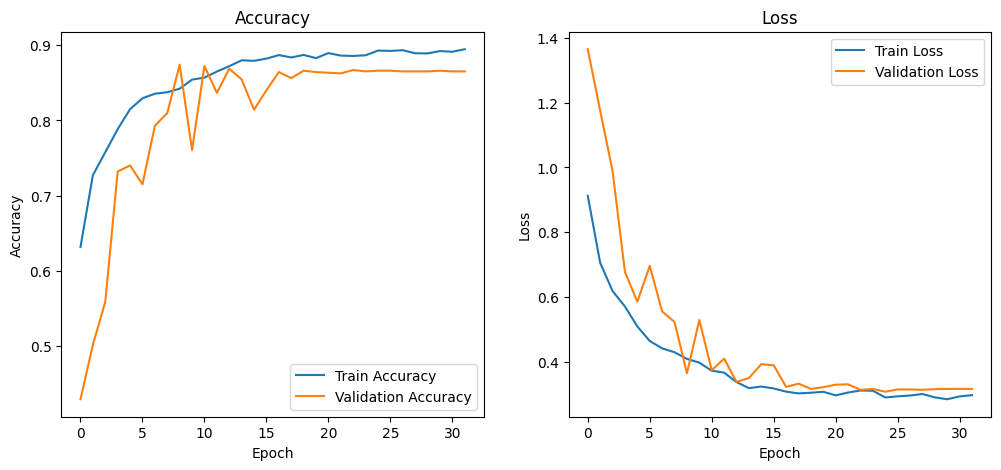

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [8]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8025 - loss: 0.6078
Test Loss: 0.6078
Test Accuracy: 0.8025


In [9]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      glioma       0.81      0.72      0.76       400
  meningioma       0.83      0.51      0.63       400
     notumor       0.77      0.99      0.87       400
   pituitary       0.81      0.98      0.89       400

    accuracy                           0.80      1600
   macro avg       0.81      0.80      0.79      1600
weighted avg       0.81      0.80      0.79      1600



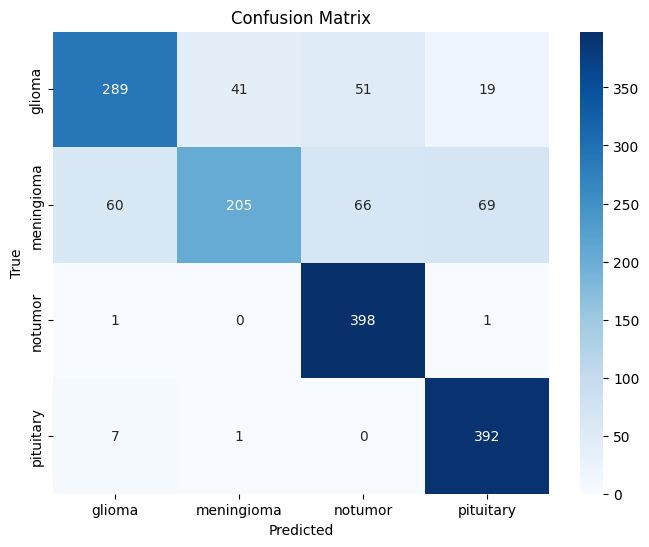

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [11]:
model.save("custom_cnn_brain_tumor.keras")

In [12]:
num_classes = len(class_names)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(img_height, img_width, 3))
x = img_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

mobilenet_model = Model(inputs, outputs, name="MobileNetV2_Transfer")

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

/tmp/ipykernel_24/1495500365.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 225, 225, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ img_augmentation (Sequential)   │ (None, 225, 225, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    "best_mobilenetv2.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

start_time = time.time()

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

mobilenet_training_time = time.time() - start_time
print(f"MobileNetV2 training time: {mobilenet_training_time:.2f} seconds")

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5672 - loss: 1.0379
Epoch 1: val_loss improved from None to 0.61795, saving model to best_mobilenetv2.keras

Epoch 1: finished saving model to best_mobilenetv2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - accuracy: 0.6518 - loss: 0.8359 - val_accuracy: 0.7563 - val_loss: 0.6179 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7258 - loss: 0.6593
Epoch 2: val_loss improved from 0.61795 to 0.58521, saving model to best_mobilenetv2.keras

Epoch 2: finished saving model to best_mobilenetv2.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.7357 - loss: 0.6416 - val_accuracy: 0.7786 - val_loss: 0.5852 - learning_rate: 0.0010
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7750 - loss: 0.5894
Epoch 3: val_loss improved from 0.58521 to 0.51597, saving model to best_mobilenetv2.keras

Epoch 3: finished saving model to best_mobilenetv2.keras
140/140 ━

In [14]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

history_mobilenet_ft = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

mobilenet_finetune_time = time.time() - start_time
print(f"MobileNetV2 fine-tuning time: {mobilenet_finetune_time:.2f} seconds")

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4473 - loss: 3.8340
Epoch 1: val_loss did not improve from 0.43193
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.5475 - loss: 2.3458 - val_accuracy: 0.6250 - val_loss: 1.3659 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7342 - loss: 0.6802
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 2: val_loss did not improve from 0.43193
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.7426 - loss: 0.6596 - val_accuracy: 0.6821 - val_loss: 1.0135 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7715 - loss: 0.5660
Epoch 3: val_loss did not improve from 0.43193
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.7688 - loss: 0.5753 - val_accuracy: 0.7375 - val_loss: 0.7669 - learning_rate: 2.0000e-06
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7732 - lo

In [15]:
mobilenet_model = tf.keras.models.load_model("best_mobilenetv2.keras")

mobilenet_test_loss, mobilenet_test_acc = mobilenet_model.evaluate(test_ds)

print(f"MobileNetV2 Test Loss: {mobilenet_test_loss:.4f}")
print(f"MobileNetV2 Test Accuracy: {mobilenet_test_acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.7506 - loss: 0.7187
MobileNetV2 Test Loss: 0.7187
MobileNetV2 Test Accuracy: 0.7506


In [16]:
num_classes = len(class_names)

eff_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

eff_base.trainable = False

inputs = layers.Input(shape=(img_height, img_width, 3))
x = img_augmentation(inputs)
x = preprocess_input(x)
x = eff_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

efficientnet_model = Model(inputs, outputs, name="EfficientNetB0_Transfer")

efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 225, 225, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ img_augmentation (Sequential)   │ (None, 225, 225, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
early_stop_eff = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_eff = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint_eff = callbacks.ModelCheckpoint(
    "best_efficientnetb0.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

start_time = time.time()

history_eff = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop_eff, reduce_lr_eff, checkpoint_eff]
)

efficientnet_training_time = time.time() - start_time
print(f"EfficientNetB0 training time: {efficientnet_training_time:.2f} seconds")

Epoch 1/15


E0000 00:00:1784180702.484694      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_Transfer_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6843 - loss: 0.7766
Epoch 1: val_loss improved from None to 0.51345, saving model to best_efficientnetb0.keras

Epoch 1: finished saving model to best_efficientnetb0.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 137ms/step - accuracy: 0.7536 - loss: 0.6170 - val_accuracy: 0.7652 - val_loss: 0.5135 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8263 - loss: 0.4532
Epoch 2: val_loss improved from 0.51345 to 0.36388, saving model to best_efficientnetb0.keras

Epoch 2: finished saving model to best_efficientnetb0.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 120ms/step - accuracy: 0.8350 - loss: 0.4369 - val_accuracy: 0.8536 - val_loss: 0.3639 - learning_rate: 0.0010
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8452 - loss: 0.3963
Epoch 3: val_loss did not improve from 0.36388
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.8498 - loss: 0.3893 - val_accuracy: 0.8509 - val_l

In [18]:
eff_base.trainable = True

for layer in eff_base.layers[:-30]:
    layer.trainable = False

efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

history_eff_ft = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop_eff, reduce_lr_eff, checkpoint_eff]
)

efficientnet_finetune_time = time.time() - start_time
print(f"EfficientNetB0 fine-tuning time: {efficientnet_finetune_time:.2f} seconds")

Epoch 1/10


E0000 00:00:1784180960.136444      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_Transfer_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7910 - loss: 0.5571
Epoch 1: val_loss did not improve from 0.25459
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 148ms/step - accuracy: 0.8078 - loss: 0.5104 - val_accuracy: 0.8750 - val_loss: 0.3150 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8347 - loss: 0.4372
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 2: val_loss did not improve from 0.25459
140/140 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.8339 - loss: 0.4374 - val_accuracy: 0.8696 - val_loss: 0.3303 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8398 - loss: 0.4044
Epoch 3: val_loss did not improve from 0.25459
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 131ms/step - accuracy: 0.8469 - loss: 0.3991 - val_accuracy: 0.8687 - val_loss: 0.3307 - learning_rate: 2.0000e-06
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8592 - loss: 0.3

In [19]:
efficientnet_model = tf.keras.models.load_model("best_efficientnetb0.keras")

eff_test_loss, eff_test_acc = efficientnet_model.evaluate(test_ds)

print(f"EfficientNetB0 Test Loss: {eff_test_loss:.4f}")
print(f"EfficientNetB0 Test Accuracy: {eff_test_acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.8644 - loss: 0.4774
EfficientNetB0 Test Loss: 0.4774
EfficientNetB0 Test Accuracy: 0.8644


MobileNetV2 achieved the best overall performance with 85% accuracy and 85% weighted F1-score. 
It outperformed the custom CNN and EfficientNetB0 while remaining lightweight, making it the most suitable model for deployment in the final application.

In [20]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [21]:
import os

os.listdir("/kaggle/working")

['best_efficientnetb0.keras',
 'best_custom_cnn.keras',
 'class_names.json',
 'best_mobilenetv2.keras',
 '__notebook__.ipynb',
 'custom_cnn_brain_tumor.keras']